# Use this Notebook to load and test report tasks

In [170]:
import dateutil.tz
from time import perf_counter

import pandas as pd
from influxdb_client import InfluxDBClient
import matplotlib.pyplot as plt

import numpy as np

import os
from dotenv import load_dotenv

Load the correct .env file for your source data

Required variables:
* INFLUX_HOST
* INFLUX_ORG
* INFLUX_DBNAME
* INFLUX_TOKEN
* INFLUX_MEAS

In [171]:
load_dotenv('doanna.env')

influx_host = os.getenv('INFLUX_HOST')
influx_org = os.getenv('INFLUX_ORG')
influx_dbname = os.getenv('INFLUX_DBNAME')
influx_token = os.getenv('INFLUX_TOKEN')
influx_meas = os.getenv('INFLUX_MEAS')

## Set Start and End Marks

The following cell is used for start and stop time using the "TimeMark" format: YYYYMMDDTHHMM
Note that these are zulu times in Minutes resolution.

* YYYYMMDDTHHMM

  * YYYY - 4-digit Year
  *  MM - 2-digit Month
  * DD - 2-digit Day
  * T - time follows in Zulu (UTC) time
  * HH - 2-digit hour - 24 hour clock
  * MM - 2-digit minute

In [173]:
start_mark = "20240505T0000"
end_mark = "20240506T0000"
## Prepare the query

# Using provided parameters, this cell prepares the query info a string variable.
influx_url = f"https://{influx_host}"
zulu_tz = dateutil.tz.gettz('UTC')
start_zulu = dateutil.parser.parse(start_mark).replace(tzinfo=zulu_tz)
start_string = start_zulu.strftime("%Y-%m-%dT%H:%M:%SZ")
end_zulu = dateutil.parser.parse(end_mark).replace(tzinfo=zulu_tz)
end_string = end_zulu.strftime("%Y-%m-%dT%H:%M:%SZ")

influx_query = f'''
    from(bucket: "{influx_dbname}")
        |> range(start: {start_string}, stop: {end_string})
        |> filter(fn:(r) => r._measurement == "{influx_meas}")
        |> drop(fn: (column) => column =~ /^_(start|stop|measurement)/)
        |> pivot(rowKey:["dev_eui","_time"], columnKey: ["_field"], valueColumn: "_value")
        |> keep(columns: ["_time","dev_eui","gateway","gateway_eui",
                "rx_time","rcv_time",
                "device_addr","counter_up",
                "duplicate","frame_size","payload_size",
                "bandwidth","datarate","payload_size",
                "spreading_factor","rssi","snr","frequency","gw_latitude","gw_longitude",
                "tag1","tag2","pluscode"])
'''


## Time for the Query

Using `perf_counter`, make the query to influxDB and report the query time.

In [174]:
start_timer = perf_counter()
with InfluxDBClient(
                    url=influx_url,
                    token=influx_token,
                    org=influx_org,
                    timeout=(5000, 60000)
                    ) as client:
    try:
        influx_results = client.query_api().query_data_frame(org=influx_org, query=influx_query)
    except Exception as e:
        report_status = F'Failed: {e}'
        print(report_status)
stop_timer = perf_counter()
query_time = round(stop_timer - start_timer, 1)

print(query_time)

0.9


## Clean the Data results

First look for a list of dataframes and process into a single dataframe if needed.

Next start dropping and renaming columns as needed.

Data cleaning and normalization.

In [175]:
# this normalizes the list into a DF by adding missing columns and appending
if type(influx_results) is list:
    append_flag = False
    df_list = influx_results
    columns_set = set([col for df in df_list for col in df.columns])
    frames_df = pd.DataFrame()
    for pdf in df_list:
        missing_cols = columns_set - set(pdf.columns)
        pdf = pdf.reindex(columns=pdf.columns.tolist() + list(missing_cols))
        if append_flag:
            frames_df = pd.concat([frames_df, pdf], axis=0)
        else:
            frames_df = pdf
            append_flag = True
    influx_pdf = frames_df.reset_index(drop=True)
else:
    influx_pdf = influx_results.copy()

if influx_pdf.shape[0] == 0:
    report_status = "Empty"
    print("no results")

influx_pdf = influx_pdf.drop(columns=['result', 'table'])

# fix a few inconsistent column names
if 'rx_time' not in influx_pdf.columns and 'rcv_time' in influx_pdf.columns:
    influx_pdf = influx_pdf.rename(columns={'rcv_time': 'rx_time'})
if 'gateway' not in influx_pdf.columns and 'gateway_eui' in influx_pdf.columns:
    influx_pdf = influx_pdf.rename(columns={'gateway_eui': 'gateway'})
if 'device_addr' not in influx_pdf.columns:
    influx_pdf['device_addr'] = 'not'

# print(influx_pdf.info())

### More Data Cleaning

Setup columns as correct types.

Change some columns to categories.

In [176]:
# make a copy again for column typing
pdf = influx_pdf.copy().sort_values(by=['dev_eui', '_time']).reset_index(drop=True)

# Setup Data Types in dataframe
pdf = pdf.astype({
    'counter_up': 'Int64',
    'rx_time': 'string',
    'bandwidth': 'Int64',
    'spreading_factor': 'Int64',
    'rssi': 'Int64',
    'frequency': 'string',
})
# set Data Types only if the column exists
if 'datarate' in pdf.columns:
    pdf = pdf.astype({'datarate': 'Int64'})
if 'frame_size' in pdf.columns:
    pdf = pdf.astype({'frame_size': 'Int64'})
if 'payload_size' in pdf.columns:
    pdf = pdf.astype({'payload_size': 'Int64'})
#
if 'tag1' in pdf.columns:
    pdf = pdf.astype({'tag1': 'string'})
if 'tag2' in pdf.columns:
    pdf = pdf.astype({'tag2': 'string'})

# change low cardinality to category for memory savings
pdf = pdf.astype({
    'frequency': 'category',
    'bandwidth': 'category',
    'gateway': 'category',
})
if 'datarate' in pdf.columns:
    pdf = pdf.astype({'datarate': 'category'})

## Gateway Tables

Start a new frames_df copy and work on gateway tables.

First the gw_info_df, then gw_freqs_df


In [177]:
# new copy now called "frames_df" to align with django code
frames_df = pdf.copy()
# is gateway location provided (talking to you ran-bridge)
if 'gw_latitude' in frames_df.columns and 'gw_longitude' in frames_df.columns:
    gw_info_df = frames_df[['gateway', 'gw_latitude', 'gw_longitude']] \
        .drop_duplicates() \
        .dropna() \
        .reset_index(drop=True)
    # only one location per gateway in case of GPS change
    gw_info_df = gw_info_df.drop_duplicates(subset=['gateway'])
    gw_info_df = gw_info_df.rename(columns={'gw_latitude': 'lat', 'gw_longitude': 'long'})
else:
    # create a blank dataframe for return - No Locations for Gateways!
    gw_info_df = pd.DataFrame()

gw_info_df = gw_info_df.set_index('gateway')

# # count frames per gateway in frames_df
# gateway_frame_counts = frames_df['gateway'].value_counts()
# gateway_frame_counts.columns = ['gateway', 'frame_count']
gw_framecount_df = frames_df.groupby(['gateway'],
                                     observed=False).size().to_frame("frames")

gw_info_df = gw_info_df.join(gw_framecount_df)


In [178]:
device_uplink_list = frames_df.groupby(["dev_eui", "device_addr", "counter_up"], as_index=False).agg(
    uplink_hits=pd.NamedAgg(column="counter_up", aggfunc="count"),
    uplink_first=pd.NamedAgg(column="_time", aggfunc="min"),
    uplink_last=pd.NamedAgg(column="_time", aggfunc="max"),
    uplink_diff=pd.NamedAgg(column="_time", aggfunc=lambda t: (t.max() - t.min()).microseconds / 1000)
)
# create an order for the device_addr (joins)
ordered_addrs = device_uplink_list.sort_values(["dev_eui", "uplink_first"])["device_addr"].unique()
device_uplink_list["device_addr"] = pd.Categorical(device_uplink_list["device_addr"], categories=ordered_addrs)
# add columns - start with Diff
device_uplink_list['diff'] = (
    device_uplink_list.groupby(['dev_eui', 'device_addr'], observed=True)['counter_up']
    .diff() - 1
)
# fill sequence start (na) with 0, set to integer
device_uplink_list['diff'] = device_uplink_list['diff'].fillna(0).astype(int)

device_uplinks_df = frames_df.groupby(['dev_eui'], observed=True).agg(
    frames_received=pd.NamedAgg(column='counter_up', aggfunc='count'),
    gateways=pd.NamedAgg(column='gateway', aggfunc=lambda j: j.nunique()),
    join_seqs=pd.NamedAgg(column='device_addr', aggfunc=lambda j: j.nunique()),
    frame_first=pd.NamedAgg(column='_time', aggfunc='min'),
    frame_last=pd.NamedAgg(column='_time', aggfunc='max'),
)

# add summary data from uplinks
device_uplinks2_df = device_uplink_list.groupby(['dev_eui']).agg(
    uplinks_received=pd.NamedAgg(column='counter_up', aggfunc='count'),
    uplinks_missed=pd.NamedAgg(column='diff', aggfunc='sum'),
)
device_uplinks_df = device_uplinks_df.join(device_uplinks2_df)

device_uplinks_df['uplinks_total'] = device_uplinks_df['uplinks_received'] + device_uplinks_df['uplinks_missed']

device_uplinks_df['uplinks_pdr'] = round(
    device_uplinks_df['uplinks_received'] / device_uplinks_df['uplinks_total'],
    3
)

In [179]:
# Device GW DF - Tracking performance by gateway
device_gw_df = frames_df.groupby(['dev_eui', 'gateway'], observed=True).agg(
    # observed = True,
    frame_count=pd.NamedAgg(column='counter_up', aggfunc='size'),
    rssi_mean=pd.NamedAgg(column='rssi', aggfunc='mean'),
    rssi_std=pd.NamedAgg(column='rssi', aggfunc='std'),
    rssi_min=pd.NamedAgg(column='rssi', aggfunc='min'),
    rssi_max=pd.NamedAgg(column='rssi', aggfunc='max'),
    snr_mean=pd.NamedAgg(column='snr', aggfunc='mean'),
    snr_std=pd.NamedAgg(column='snr', aggfunc='std'),
    snr_min=pd.NamedAgg(column='snr', aggfunc='min'),
    snr_max=pd.NamedAgg(column='snr', aggfunc='max'),
).round(1)
# device_gw_df = device_gw_df[device_gw_df['frame_count'] != 0]
device_gw_df['rssi_std'] = device_gw_df['rssi_std'].fillna(0)
device_gw_df['snr_std'] = device_gw_df['snr_std'].fillna(0)
device_gw_df = device_gw_df.astype({
    'rssi_min': 'int',
    'rssi_max': 'int',
})
device_gw_df = device_gw_df.join(device_uplinks_df['uplinks_total'], on='dev_eui').reset_index()


In [180]:
print(device_gw_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   dev_eui        496 non-null    object  
 1   gateway        496 non-null    category
 2   frame_count    496 non-null    Int64   
 3   rssi_mean      496 non-null    Float64 
 4   rssi_std       496 non-null    Float64 
 5   rssi_min       496 non-null    int64   
 6   rssi_max       496 non-null    int64   
 7   snr_mean       496 non-null    float64 
 8   snr_std        496 non-null    float64 
 9   snr_min        496 non-null    float64 
 10  snr_max        496 non-null    float64 
 11  uplinks_total  496 non-null    Int64   
dtypes: Float64(2), Int64(2), category(1), float64(4), int64(2), object(1)
memory usage: 45.5+ KB
None


In [181]:

devices_per_gateway = device_gw_df.groupby('gateway', observed=False)['dev_eui'].nunique()

gw_info_df = gw_info_df.join(devices_per_gateway)

gw_info_df = gw_info_df.rename(columns={'dev_eui': 'devices'})

print(gw_info_df.info())

<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 7 entries, 647fda019edb0000 to 647fda01c5a20000
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   lat      7 non-null      float64
 1   long     7 non-null      float64
 2   frames   7 non-null      int64  
 3   devices  7 non-null      int64  
dtypes: float64(2), int64(2)
memory usage: 775.0 bytes
None


In [182]:
# gw_info_df = gw_info_df.sort_values('devices', ascending=True).reset_index()
gw_device_counts = gw_info_df[['devices']].sort_values(['devices']).reset_index()
print(gw_device_counts.info())
print(gw_device_counts)

# gw_device_counts = gw_device_counts
# print(gw_device_counts.info())
# print(gw_device_counts)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   gateway  7 non-null      category
 1   devices  7 non-null      int64   
dtypes: category(1), int64(1)
memory usage: 547.0 bytes
None
            gateway  devices
0  647fda019edb0000       28
1  647fda01c6b30000       41
2  647fda01c5690000       60
3  647fda01c5a20000       68
4  647fda019ef00000       74
5  647fda019e7f0000       99
6  647fda01c5870000      126


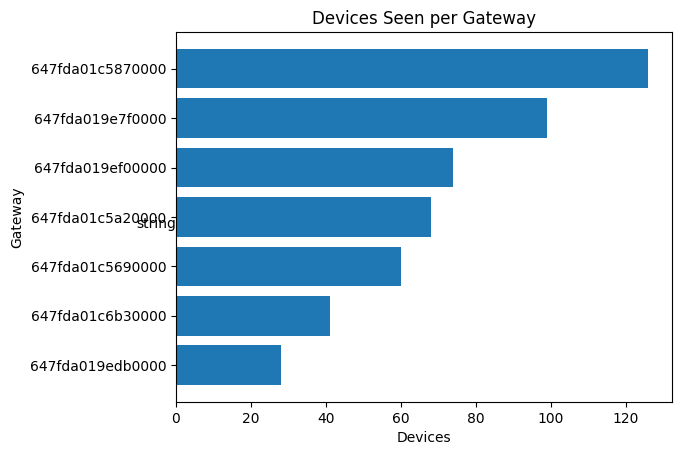

In [137]:
plt.barh(gw_device_counts['gateway'], gw_info_df['devices'])
plt.title("Devices Seen per Gateway")
plt.xlabel('Devices')
plt.ylabel('Gateway')

# # Add labels to each bar
# for row in gw_info_df.iterrows():
#     plt.text(r
# w['gateway'], row['devices'], row['devices'], ha='center', va='bottom')

plt.text(0.1, 3, 'string', ha='right', va='top')

# Display the plot
plt.show()


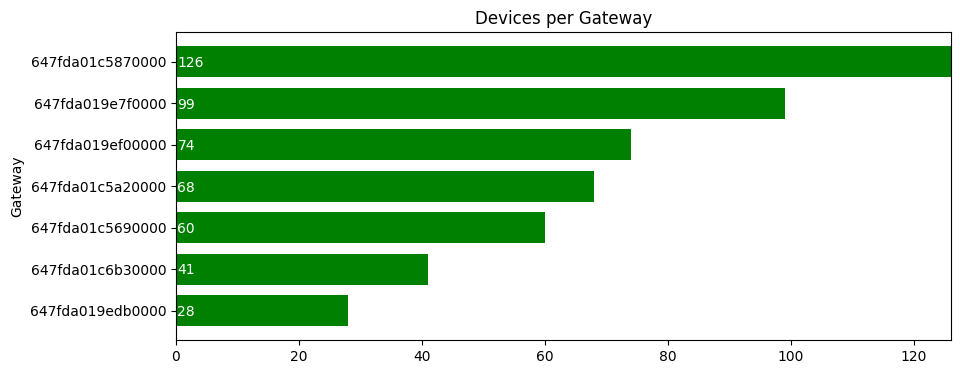

In [197]:
x = gw_device_counts['gateway']
y = gw_device_counts['devices']

fig, ax = plt.subplots(figsize=(10, 4))

width = 0.75 # the width of the bars
ind = np.arange(len(y))  # the x locations for the groups
bar_plot = ax.barh(ind, y, width, color="green", align='edge')
ax.set_yticks(ind+width/2)
ax.set_yticklabels(x, minor=False)

def autolabel(bar_plot):
    for idx,rect in enumerate(bar_plot):
        ax.text(0.25, idx+.25, y[idx], color = 'white')
autolabel(bar_plot)

plt.margins(0,0.05)
plt.title('Devices per Gateway')
plt.ylabel('Gateway')

# Rest of your code...

plt.show()


In [185]:
print(type(fig))

<class 'matplotlib.figure.Figure'>


In [ ]:

gw_freqs_df = frames_df.groupby(['gateway', 'frequency'],
                                observed=False).size().to_frame("frames")
gw_freqs_df = gw_freqs_df.reset_index().pivot(index='gateway', columns='frequency', values='frames')

gw_freqs_df = gw_freqs_df.join(gw_framecount_df)

count_col = gw_freqs_df.pop('frames')
gw_freqs_df.insert(0, 'frames', count_col)
gw_freqs_df = gw_freqs_df.sort_values('frames', ascending=False)

## Create a graph of frequency totals

Use a panda sum() and cerate the plot.

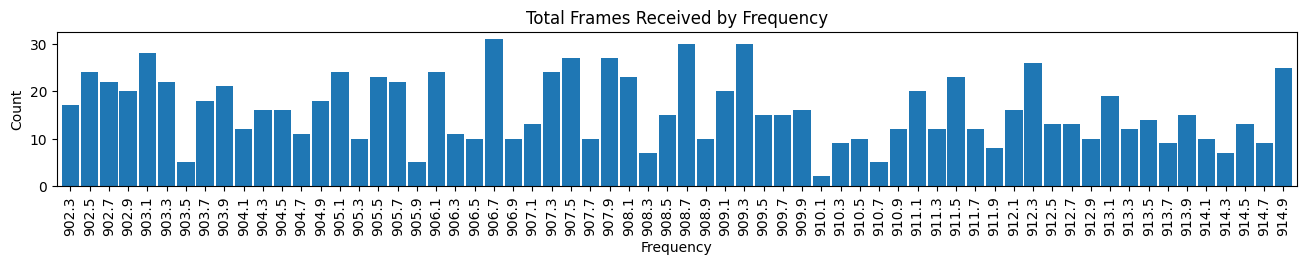

In [9]:
# gw_freqs_df = gw_freqs_df.drop('frames', axis=1)
total_freqs = gw_freqs_df.drop('frames', axis=1).sum()

plt.figure(figsize=(16, 2))
total_freqs.plot.bar(width=0.9)
plt.title("Total Frames Received by Frequency")
plt.xlabel("Frequency")
plt.ylabel("Count")
plt.show()


Now Graph Device and Frame counts

## Now create graphs for all gateways

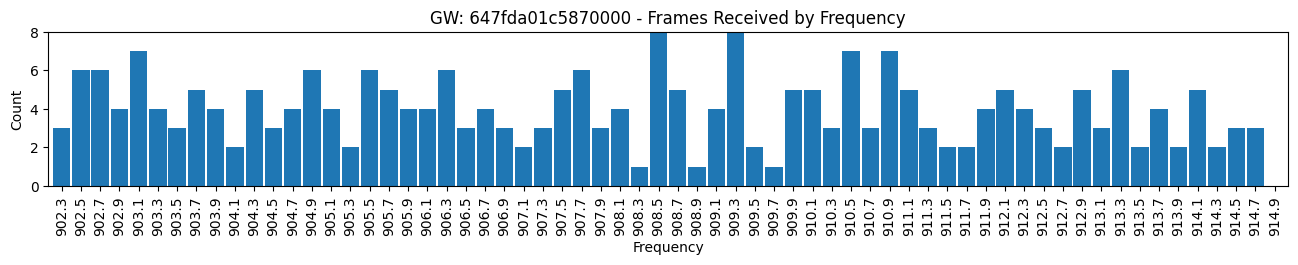

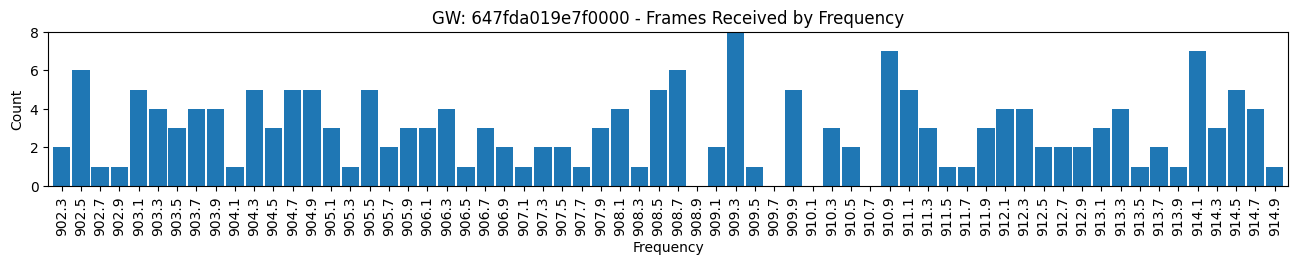

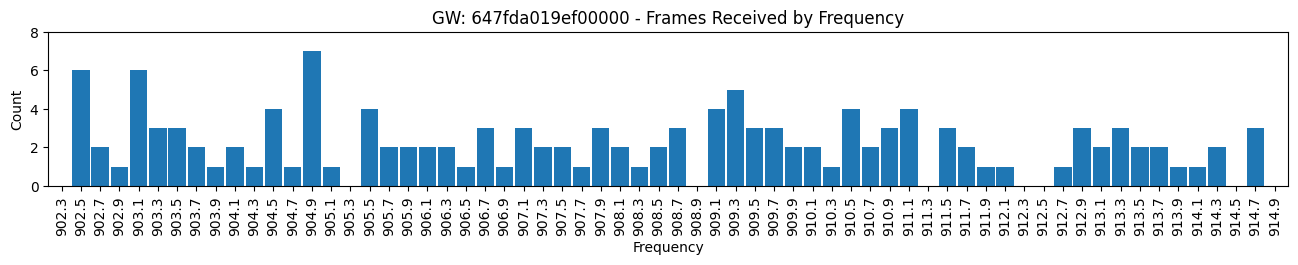

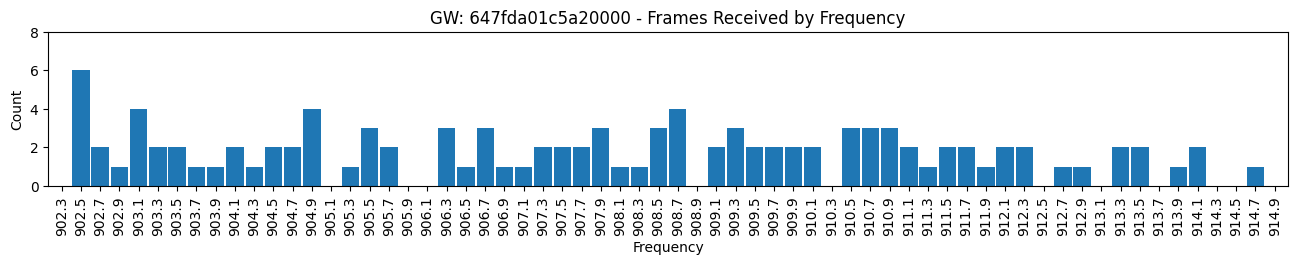

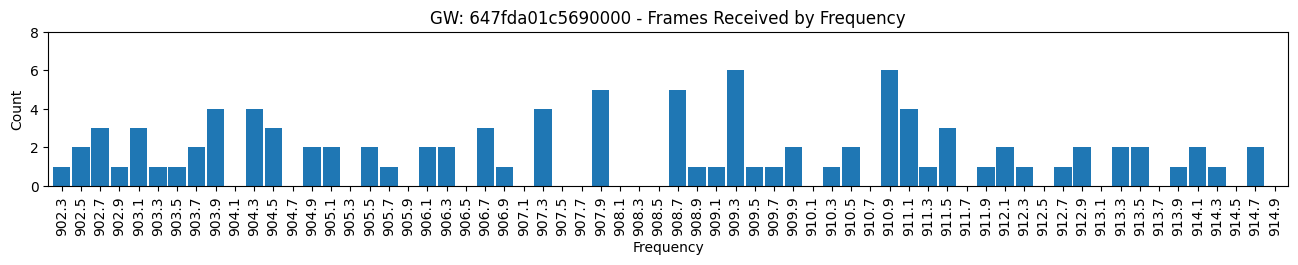

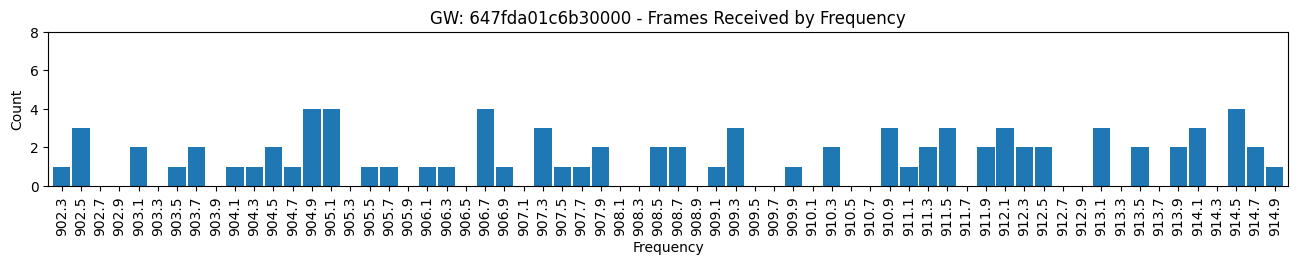

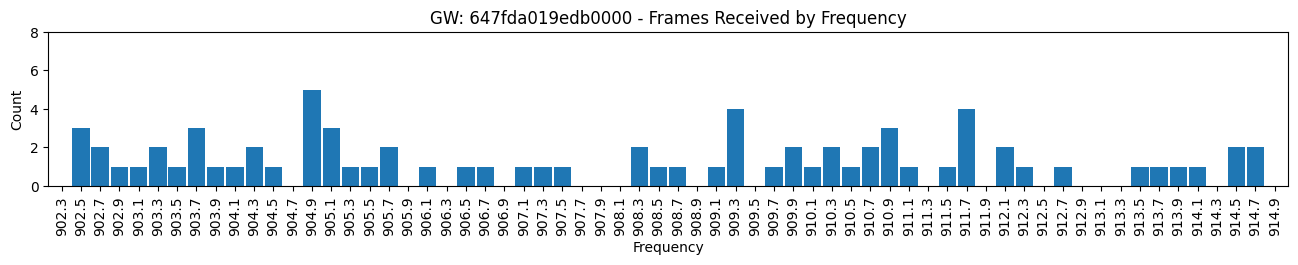

In [12]:
max_count = gw_freqs_df.drop('frames',axis=1).max().max()
# Create a bar chart for each gateway in gw_freqs_df

for gateway in gw_freqs_df.index:
    plt.figure(figsize=(16, 2))
    freqs = gw_freqs_df.loc[gateway].drop('frames')
    freqs.plot.bar(width=0.9)
    plt.title(f"GW: {gateway} - Frames Received by Frequency")
    plt.xlabel("Frequency")
    plt.ylabel("Count")
    plt.ylim(0, max_count)
    plt.show()


## Build Spreading Factor summary data

* Need Average (Mean) spreading factor by device
* Need counts of each spreading factor by device

In [110]:
frames_df = pdf.copy()

sf_df = frames_df.groupby('dev_eui')['spreading_factor'].mean().round(1).to_frame('avg')

sf_summ_df = frames_df.groupby(['dev_eui','spreading_factor'], observed=False).size().to_frame("frames").reset_index()
sf_summ_df = sf_summ_df.pivot(index='dev_eui', columns='spreading_factor', values='frames').fillna(0).astype('int')

sf_df = sf_df.join(sf_summ_df).add_prefix('sf_')

print(sf_df.info())
print(sf_df.head(5))

<class 'pandas.core.frame.DataFrame'>
Index: 187 entries, 0c57eb00000e78b8 to 0c57eb000018a8d3
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sf_avg  187 non-null    Float64
 1   sf_7    187 non-null    int64  
 2   sf_8    187 non-null    int64  
 3   sf_9    187 non-null    int64  
 4   sf_10   187 non-null    int64  
dtypes: Float64(1), int64(4)
memory usage: 8.9+ KB
None
                  sf_avg  sf_7  sf_8  sf_9  sf_10
dev_eui                                          
0c57eb00000e78b8     8.0     0     1     0      0
0c57eb00000ece32     9.0     0     0     2      0
0c57eb00000ece33     8.0     0     3     0      0
0c57eb00000ece34     8.0     0     2     0      0
0c57eb00000ece35     9.0     0     0    13      0
